Normal: 15
Tuberculosis: 15


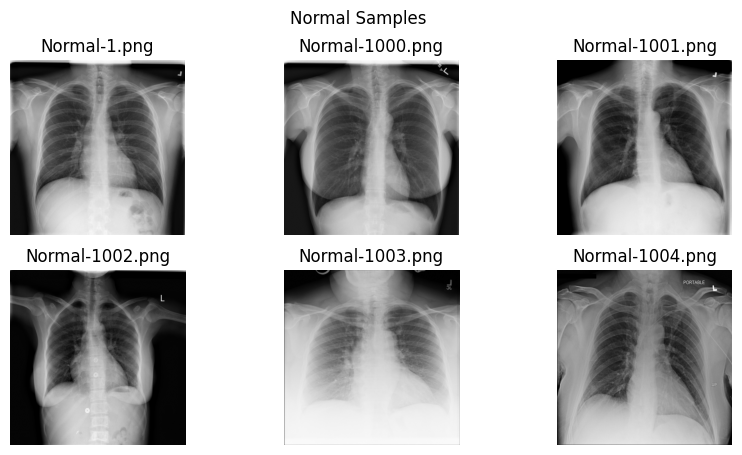

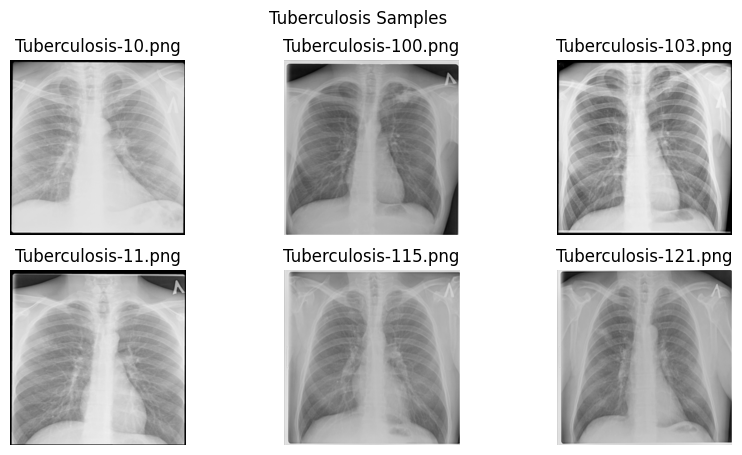

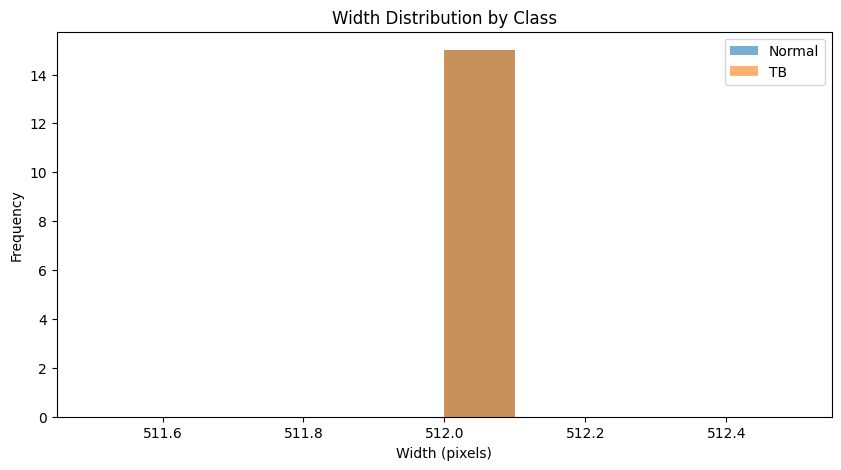


DEBUG — Pixel counts before histogram:
Normal pixels: 3932160
TB pixels: 3932160


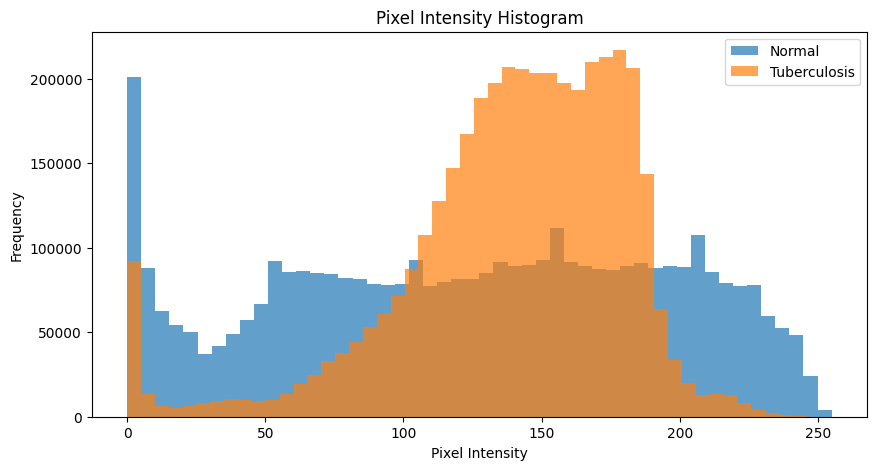


Outliers in Normal:

Outliers in Tuberculosis:


In [1]:
import os
import cv2
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

# Paths definition
RAW_PATH = "../raw/"
NORMAL_PATH = RAW_PATH + "normal/"
TB_PATH = RAW_PATH + "tuberculosis/"

# Counter image of each class
normal_imgs = os.listdir(NORMAL_PATH)
tb_imgs = os.listdir(TB_PATH)

print(f"Normal: {len(normal_imgs)}")
print(f"Tuberculosis: {len(tb_imgs)}")

# Display samples images.
def show_samples(path, title):
    imgs = os.listdir(path)[:6]  # first 6 samples per class
    plt.figure(figsize=(10,5))
    for i, img in enumerate(imgs):
        img_path = os.path.join(path, img)
        img_data = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        plt.subplot(2,3,i+1)
        plt.imshow(img_data, cmap ="gray")
        plt.title(img)
        plt.axis("off")
    plt.suptitle(title, fontsize = 12)

    os.makedirs("results/exploration", exist_ok=True)
    plt.savefig(f"results/exploration/{title.replace(' ', '_').lower()}.png",
                dpi=300, bbox_inches="tight")
    plt.show()

show_samples(NORMAL_PATH, "Normal Samples")
show_samples(TB_PATH, "Tuberculosis Samples")

# Image size distribution
# The datasets are standarizated (meaning they have the same sizes)

dims = []

for cls, path in [("Normal", NORMAL_PATH), ("TB", TB_PATH)]:
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        h, w = img.shape
        dims.append([cls, w, h])

dim_df = pd.DataFrame(dims, columns = ["Class", "Width", "Height"])

plt.figure(figsize = (10,5))
plt.hist(dim_df[dim_df["Class"] == "Normal"]["Width"], alpha = 0.6, label = "Normal")
plt.hist(dim_df[dim_df["Class"] == "TB"]["Width"], alpha = 0.6, label = "TB")
plt.title("Width Distribution by Class")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")
plt.legend()
plt.legend()
plt.savefig("results/exploration/width_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

"""
    Pixel Intensity Histograms
    Blue Histogram
    Distribute all the values, if they are close to 0 they show that the lungs 
    are empty = without tuberculosis
    In other case, if the distribution of intensity is between 50-220
    that's the normal intensity of ray X.

    Orange Histogram
    The concentration is between 120-200, if tey have tuberculosis
    they tend to have more "white" and dense marks in the radiography

"""
normal_pixels = []
tb_pixels = []

for img_name in os.listdir(NORMAL_PATH):
    img = cv2.imread(os.path.join(NORMAL_PATH, img_name), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        normal_pixels.extend(img.flatten())

for img_name in os.listdir(TB_PATH):
    img = cv2.imread(os.path.join(TB_PATH, img_name), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        tb_pixels.extend(img.flatten())

print("\nDEBUG — Pixel counts before histogram:")
print("Normal pixels:", len(normal_pixels))
print("TB pixels:", len(tb_pixels))

def plot_histogram(class_path, label):
    pixels = []
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            pixels.extend(img.flatten())

    plt.hist(pixels, bins = 50, alpha = 0.7, label = label)

plt.figure(figsize=(10,5))
plot_histogram(NORMAL_PATH, "Normal")
plot_histogram(TB_PATH, "Tuberculosis")
plt.title("Pixel Intensity Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("results/exploration/pixel_intensity_histogram.png",
            dpi = 300, bbox_inches = "tight")
plt.show()


# Outlier detection (brightness-based)
# The main objetive is to normalize or remove the extreme brightness.
def detect_outliers(path, label):
    outliers = []
    for img_name in os.listdir(path):
        img = cv2.imread(os.path.join(path, img_name), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        mean_intensity = img.mean()

        # too dark or too bright (heuristic)
        if mean_intensity < 40 or mean_intensity > 200:
            outliers.append((img_name, mean_intensity))

    print(f"\nOutliers in {label}:")
    for name, val in outliers:
        print(f"{name} -> mean={val}")

detect_outliers(NORMAL_PATH, "Normal")
detect_outliers(TB_PATH, "Tuberculosis")
